In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.cloud import bigquery
from google.oauth2 import service_account

KEYFILE = r"C:\Users\sansk\Documents\Spring-26\gcp_secret_service\damagereport-499916-f3d6c433577c.json"
PROJECT = "damagereport-499916"

creds = service_account.Credentials.from_service_account_file(
    KEYFILE,
    scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
client = bigquery.Client(project=PROJECT, credentials=creds)

print("Connected")

Connected


In [2]:
query = """
    SELECT
        event_type_group,
        state,
        region,
        decade,
        event_year,
        EXTRACT(MONTH FROM begin_datetime) AS event_month,
        deaths_direct,
        injuries_direct,
        total_damage_2024_usd
    FROM `damagereport-499916.dbt_staging.int_events_enriched`
    WHERE is_pre_standardization = FALSE
      AND event_year < 2026
      AND event_type_group IS NOT NULL
      AND region IS NOT NULL
"""

df = client.query(query).result().to_dataframe()
df['is_fatal'] = (df['deaths_direct'] > 0).astype(int)

print(f"Shape: {df.shape}")
print(f"Fatal rate: {df['is_fatal'].mean():.4%}")
df.describe()

C:\Users\sansk\Documents\Spring-26\DamageReport\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Shape: (1720900, 10)
Fatal rate: 0.6030%


,decade,event_year,event_month,deaths_direct,injuries_direct,total_damage_2024_usd,is_fatal
count,1720900.0,1720900.0,1720900.0,1720900.0,1720900.0,1.720900e+06,1.720900e+06
mean,2006.952926,2011.380349,5.956445,0.01083,0.049611,5.021615e+05,6.029984e-03
std,9.39406,8.548054,3.072513,0.59272,2.553394,4.520191e+07,7.741852e-02
min,1990.0,1996.0,1.0,0.0,0.0,0.000000e+00,0.000000e+00
25%,2000.0,2004.0,4.0,0.0,0.0,0.000000e+00,0.000000e+00
50%,2010.0,2011.0,6.0,0.0,0.0,0.000000e+00,0.000000e+00
75%,2010.0,2019.0,8.0,0.0,0.0,0.000000e+00,0.000000e+00
max,2020.0,2025.0,12.0,638.0,1150.0,2.875081e+10,1.000000e+00


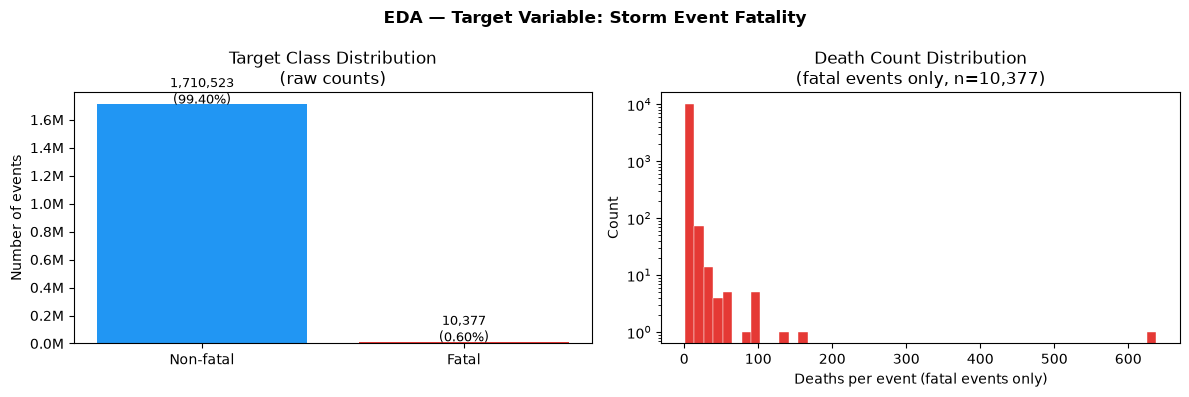

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


counts = df['is_fatal'].value_counts()
ax1.bar(['Non-fatal', 'Fatal'], counts.values,
        color=['#2196F3', '#E53935'])
ax1.set_title('Target Class Distribution\n(raw counts)')
ax1.set_ylabel('Number of events')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(counts.values):
    ax1.text(i, v + 5000, f'{v:,}\n({v/len(df):.2%})', ha='center', fontsize=9)

# Deaths distribution 
fatal_events = df[df['deaths_direct'] > 0]['deaths_direct']
ax2.hist(fatal_events, bins=50, color='#E53935', edgecolor='white', linewidth=0.3)
ax2.set_xlabel('Deaths per event (fatal events only)')
ax2.set_ylabel('Count')
ax2.set_title(f'Death Count Distribution\n(fatal events only, n={len(fatal_events):,})')
ax2.set_yscale('log')

plt.suptitle('EDA — Target Variable: Storm Event Fatality', fontweight='bold')
plt.tight_layout()
plt.show()

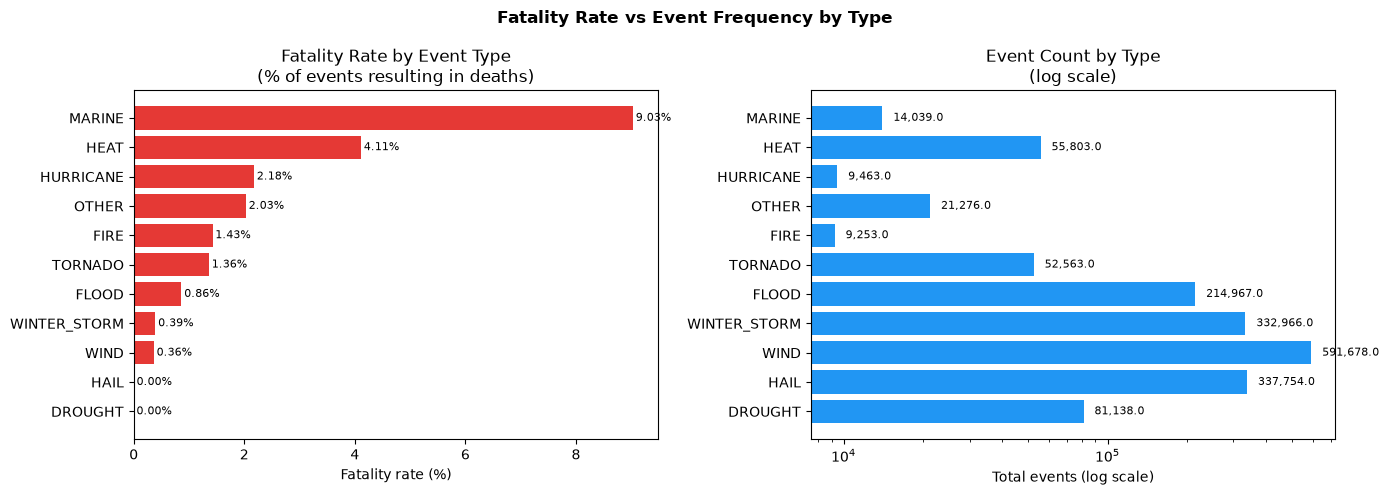

In [4]:
fatality_by_type = (df.groupby('event_type_group')
                      .agg(total_events=('is_fatal', 'count'),
                           fatal_events=('is_fatal', 'sum'))
                      .assign(fatality_rate=lambda x: x['fatal_events'] / x['total_events'] * 100)
                      .sort_values('fatality_rate', ascending=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fatality rate
ax1.barh(fatality_by_type.index, fatality_by_type['fatality_rate'], color='#E53935')
ax1.set_xlabel('Fatality rate (%)')
ax1.set_title('Fatality Rate by Event Type\n(% of events resulting in deaths)')
for i, (idx, row) in enumerate(fatality_by_type.iterrows()):
    ax1.text(row['fatality_rate'] + 0.05, i, f"{row['fatality_rate']:.2f}%", va='center', fontsize=8)

# Event count 
ax2.barh(fatality_by_type.index, fatality_by_type['total_events'], color='#2196F3')
ax2.set_xlabel('Total events (log scale)')
ax2.set_xscale('log')
ax2.set_title('Event Count by Type\n(log scale)')
for i, (idx, row) in enumerate(fatality_by_type.iterrows()):
    ax2.text(row['total_events'] * 1.1, i, f"{row['total_events']:,}", va='center', fontsize=8)

plt.suptitle('Fatality Rate vs Event Frequency by Type', fontweight='bold')
plt.tight_layout()
plt.show()

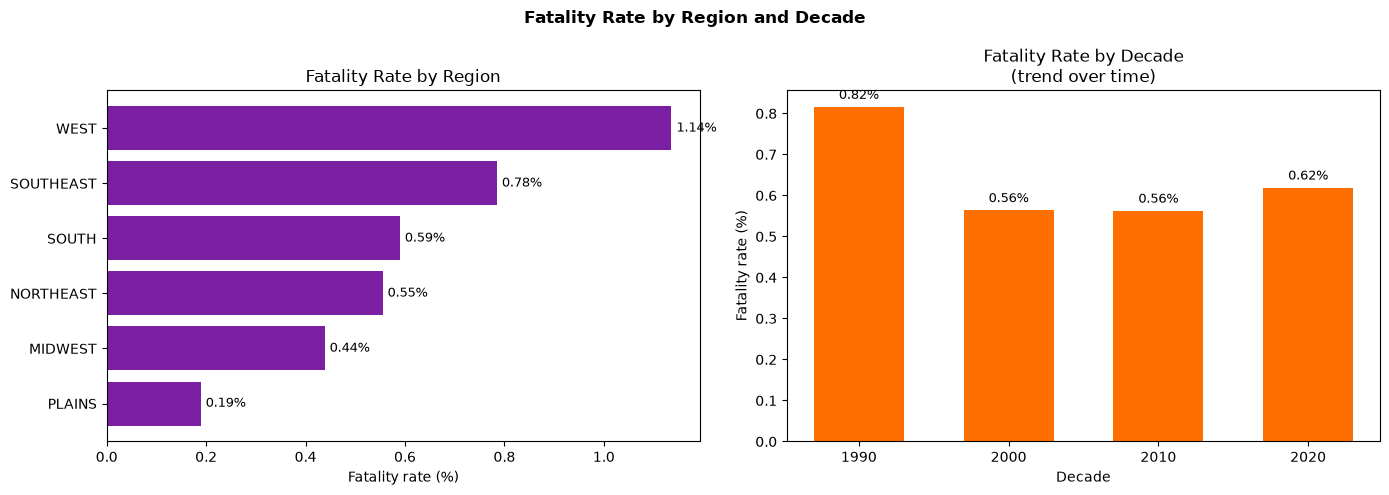

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# By region
fatality_by_region = (df.groupby('region')
                        .agg(total=('is_fatal','count'), fatal=('is_fatal','sum'))
                        .assign(rate=lambda x: x['fatal']/x['total']*100)
                        .sort_values('rate', ascending=True))

ax1.barh(fatality_by_region.index, fatality_by_region['rate'], color='#7B1FA2')
ax1.set_xlabel('Fatality rate (%)')
ax1.set_title('Fatality Rate by Region')
for i, (idx, row) in enumerate(fatality_by_region.iterrows()):
    ax1.text(row['rate'] + 0.01, i, f"{row['rate']:.2f}%", va='center', fontsize=9)

# By decade
fatality_by_decade = (df.groupby('decade')
                        .agg(total=('is_fatal','count'), fatal=('is_fatal','sum'))
                        .assign(rate=lambda x: x['fatal']/x['total']*100)
                        .sort_values('decade'))

ax2.bar(fatality_by_decade.index.astype(str), fatality_by_decade['rate'], color='#FF6F00', width=0.6)
ax2.set_xlabel('Decade')
ax2.set_ylabel('Fatality rate (%)')
ax2.set_title('Fatality Rate by Decade\n(trend over time)')
for i, (idx, row) in enumerate(fatality_by_decade.iterrows()):
    ax2.text(i, row['rate'] + 0.02, f"{row['rate']:.2f}%", ha='center', fontsize=9)

plt.suptitle('Fatality Rate by Region and Decade', fontweight='bold')
plt.tight_layout()
plt.show()

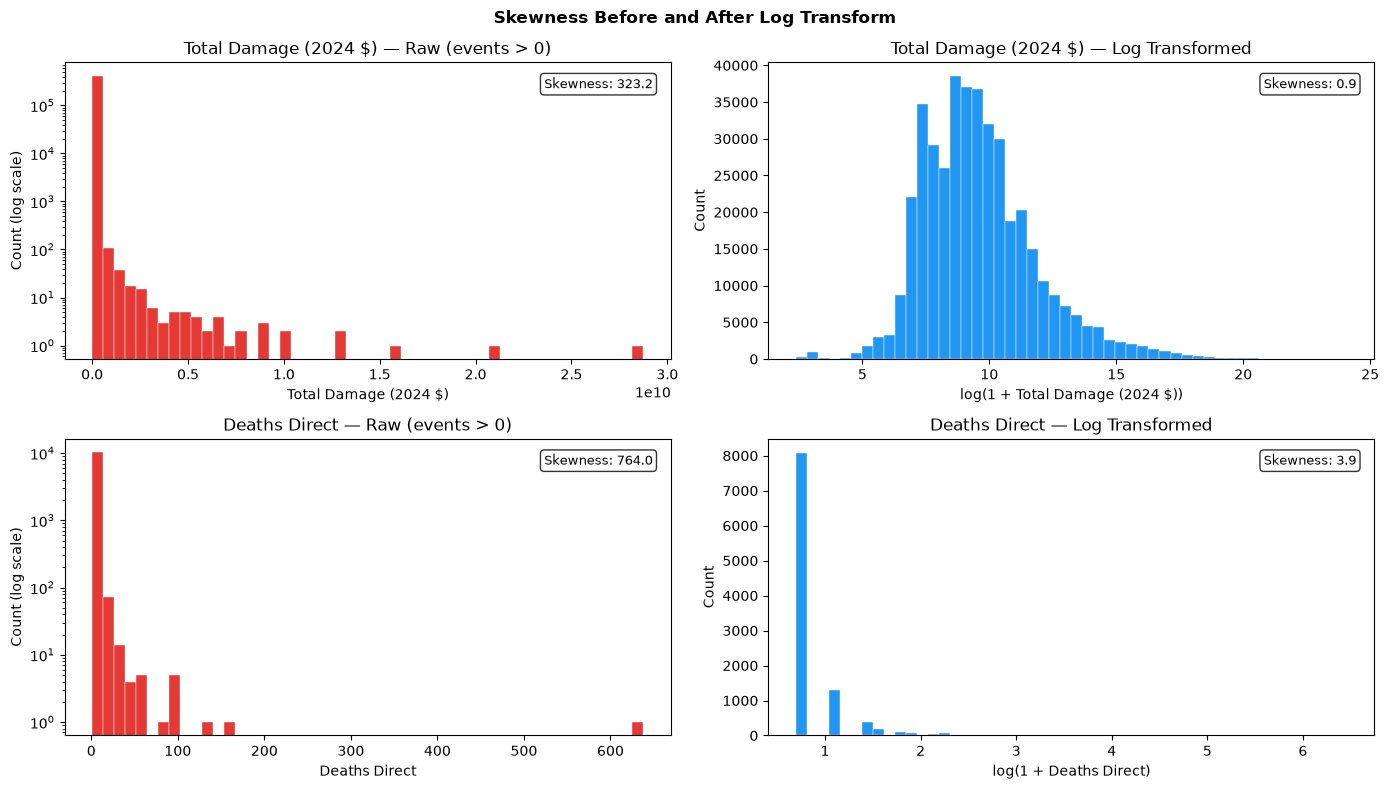

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

cols = {
    'total_damage_2024_usd': 'Total Damage (2024 $)',
    'deaths_direct': 'Deaths Direct'
}

for col_idx, (col, label) in enumerate(cols.items()):
    raw = df[col].astype(float)
    log_vals = np.log1p(raw[raw > 0])

    # Raw distribution
    axes[col_idx][0].hist(raw[raw > 0], bins=50, color='#E53935', edgecolor='white', linewidth=0.3)
    axes[col_idx][0].set_title(f'{label} — Raw (events > 0)')
    axes[col_idx][0].set_yscale('log')
    axes[col_idx][0].set_xlabel(label)
    axes[col_idx][0].set_ylabel('Count (log scale)')
    skew = raw.skew()
    axes[col_idx][0].text(0.97, 0.95, f'Skewness: {skew:.1f}',
                          transform=axes[col_idx][0].transAxes,
                          ha='right', va='top', fontsize=9,
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Log-transformed
    axes[col_idx][1].hist(log_vals, bins=50, color='#2196F3', edgecolor='white', linewidth=0.3)
    axes[col_idx][1].set_title(f'{label} — Log Transformed')
    axes[col_idx][1].set_xlabel(f'log(1 + {label})')
    axes[col_idx][1].set_ylabel('Count')
    skew_log = log_vals.skew()
    axes[col_idx][1].text(0.97, 0.95, f'Skewness: {skew_log:.1f}',
                          transform=axes[col_idx][1].transAxes,
                          ha='right', va='top', fontsize=9,
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Skewness Before and After Log Transform', fontweight='bold')
plt.tight_layout()
plt.show()

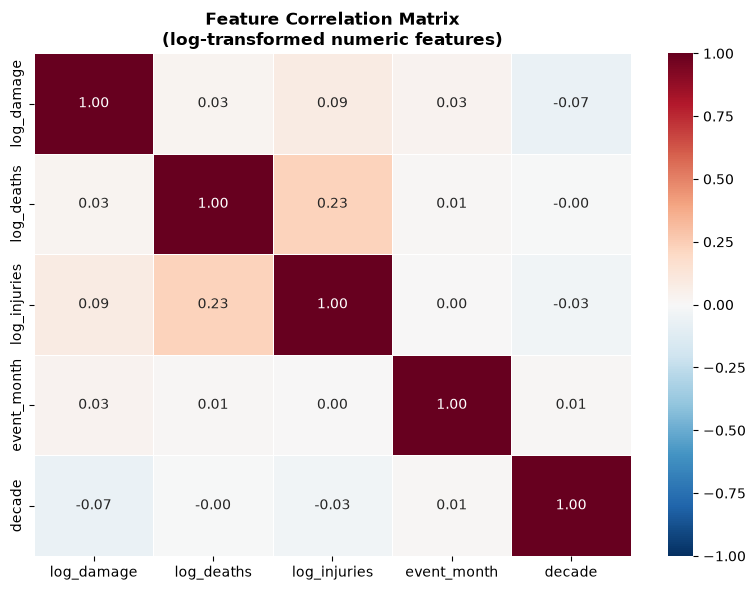

In [7]:
numeric_cols = ['total_damage_2024_usd', 'deaths_direct', 'injuries_direct', 'event_month', 'decade']

corr_df = df[numeric_cols].astype(float).copy()
corr_df['log_damage'] = np.log1p(corr_df['total_damage_2024_usd'])
corr_df['log_deaths'] = np.log1p(corr_df['deaths_direct'])
corr_df['log_injuries'] = np.log1p(corr_df['injuries_direct'])

corr_matrix = corr_df[['log_damage', 'log_deaths', 'log_injuries', 'event_month', 'decade']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix\n(log-transformed numeric features)', fontweight='bold')
plt.tight_layout()
plt.show()